# What Are Customers Really Saying?
## Amazon Review Sentiment Analysis

### Project Objective

Customer reviews provide valuable insights into customer satisfaction, product quality, and user experience.

This project uses Natural Language Processing (NLP), sentiment analysis, and data visualization to explore Amazon customer reviews and uncover patterns in customer opinions.

### Key Questions

- What is the distribution of customer ratings?
- What sentiments dominate customer reviews?
- How do ratings relate to sentiment?
- Are helpful reviews more positive or negative?
- How does review length vary across sentiment categories?
- How closely do VADER and TextBlob agree?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

from wordcloud import WordCloud

from collections import Counter

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"]=(10,6)

print("Libraries imported Successfully!")

Libraries imported Successfully!


## Load Dataset

In [2]:
df = pd.read_csv("amazon_reviews.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


## Dataset Overview

In [4]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 4915
Columns: 12


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   object 
 2   overall               4915 non-null   float64
 3   reviewText            4914 non-null   object 
 4   reviewTime            4915 non-null   object 
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
dtypes: float64(3), int64(6), object(3)
memory usage: 460.9+ KB


In [6]:
df.describe()

,Unnamed: 0,overall,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
count,4915.000000,4915.000000,4915.000000,4915.000000,4915.000000,4915.000000,4915.000000,4915.000000,4915.000000
mean,2457.000000,4.587589,437.367040,1.311089,0.210376,1.521465,1.100712,0.075468,0.020053
std,1418.982617,0.996845,209.439871,41.619161,4.023296,44.123095,39.367949,0.256062,0.077187
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-130.000000,0.000000,0.000000
25%,1228.500000,5.000000,281.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2457.000000,5.000000,431.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3685.500000,5.000000,601.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4914.000000,5.000000,1064.000000,1952.000000,183.000000,2020.000000,1884.000000,1.000000,0.957544


In [7]:
df.isnull().sum()

Unnamed: 0              0
reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

In [8]:
df["reviewerName"] = df["reviewerName"].fillna("Unknown")
df["reviewText"] = df["reviewText"].fillna("No Review")

## Data Cleaning Insight

Missing values were identified in reviewer names and review text fields. Appropriate placeholder values were used to preserve observations while maintaining dataset integrity.

In [9]:
df["review_length"] = df["reviewText"].astype(str).apply(len)

df["word_count"] = df["reviewText"].astype(str).apply(
    lambda x: len(x.split())
)

df["reviewTime"] = pd.to_datetime(df["reviewTime"])

df["year"] = df["reviewTime"].dt.year

## Rating Distribution Analysis

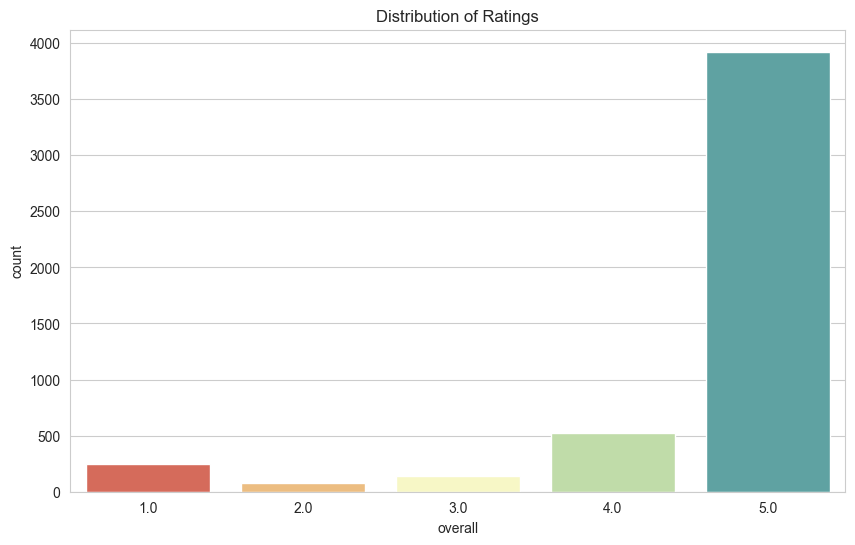

In [10]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="overall",
    data=df,
    palette="Spectral"
)

plt.title("Distribution of Ratings")
plt.show()

### Insight

Most reviews are concentrated around higher ratings, indicating generally positive customer experiences.

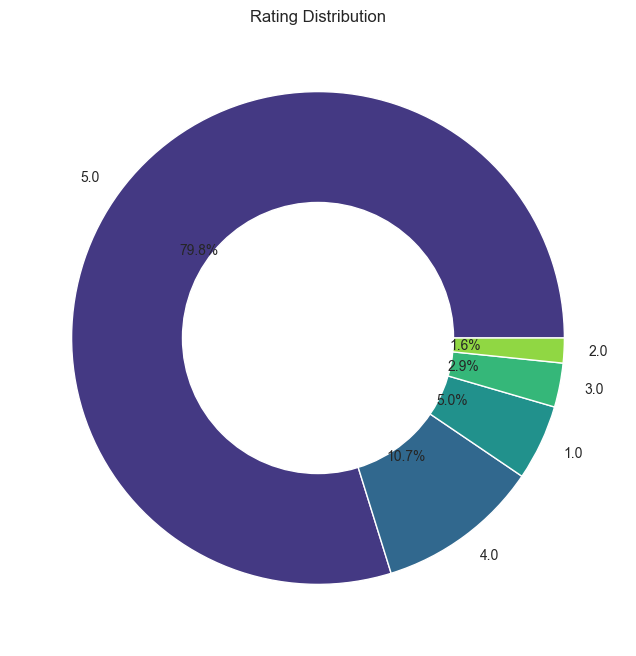

In [11]:
rating_counts = df["overall"].value_counts()

plt.figure(figsize=(8,8))

colors = sns.color_palette("viridis",len(rating_counts))

plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct="%1.1f%%",
    colors=colors
)

centre_circle = plt.Circle((0,0),0.55,fc='white')

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Rating Distribution")
plt.show()

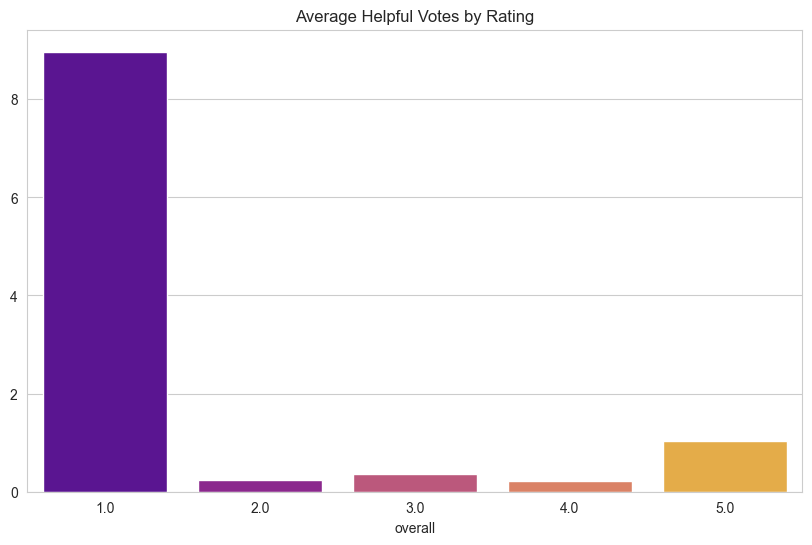

In [12]:
helpfulness = (
    df.groupby("overall")["helpful_yes"]
    .mean()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=helpfulness.index,
    y=helpfulness.values,
    palette="plasma"
)

plt.title("Average Helpful Votes by Rating")
plt.show()

### Insight

Helpful votes vary across rating levels, indicating differences in review usefulness and engagement.

## Sentiment Analysis

In [13]:
analyzer = SentimentIntensityAnalyzer()

In [14]:
df["vader_score"] = df["reviewText"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

In [15]:
def vader_label(score):

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["vader_sentiment"] = df["vader_score"].apply(vader_label)

In [16]:
df["textblob_score"] = df["reviewText"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [17]:
def textblob_label(score):

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df["textblob_sentiment"] = df["textblob_score"].apply(
    textblob_label
)

### Sentiment Overview Dashboard

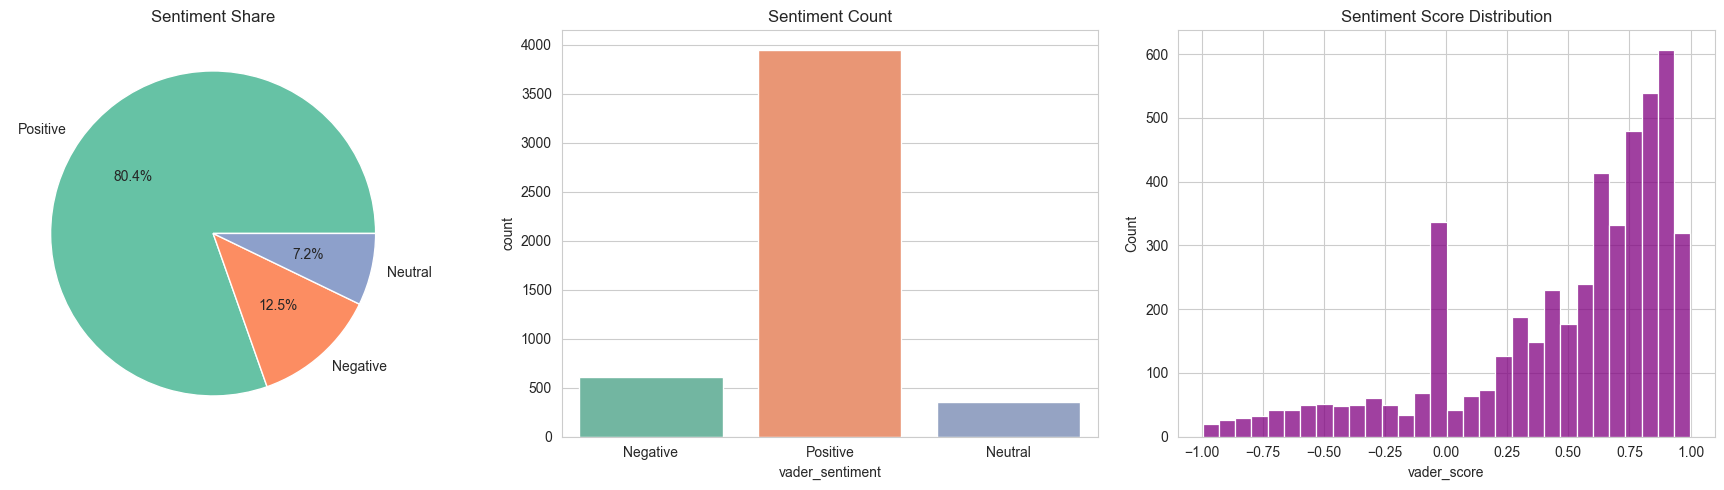

In [18]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

sent_counts = df["vader_sentiment"].value_counts()

axes[0].pie(
    sent_counts,
    labels=sent_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2")
)

axes[0].set_title("Sentiment Share")

sns.countplot(
    x="vader_sentiment",
    data=df,
    palette="Set2",
    ax=axes[1]
)

axes[1].set_title("Sentiment Count")

sns.histplot(
    df["vader_score"],
    bins=30,
    color="purple",
    ax=axes[2]
)

axes[2].set_title("Sentiment Score Distribution")

plt.tight_layout()
plt.show()

### Insight

Positive reviews dominate the dataset, reflecting favorable customer experiences and overall product satisfaction.

## Sentiment vs Rating

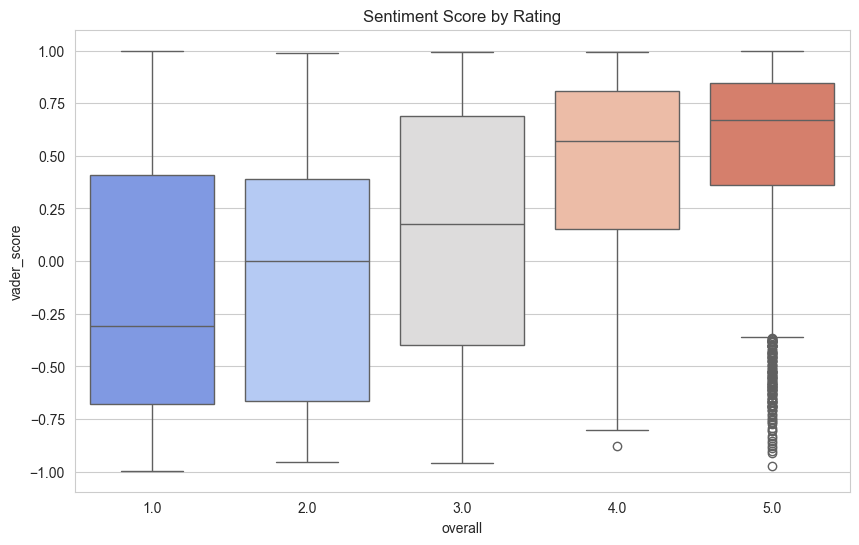

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="overall",
    y="vader_score",
    data=df,
    palette="coolwarm"
)

plt.title("Sentiment Score by Rating")
plt.show()

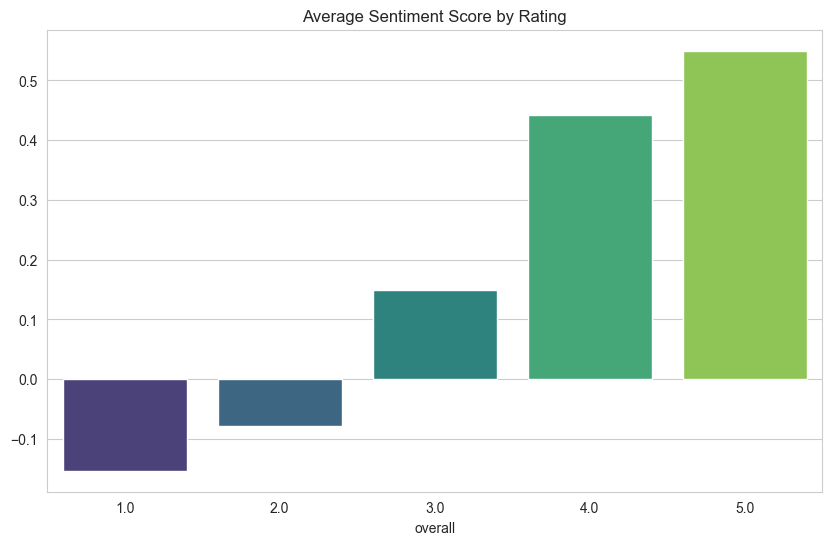

In [20]:
mean_scores = (
    df.groupby("overall")["vader_score"]
    .mean()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=mean_scores.index,
    y=mean_scores.values,
    palette="viridis"
)

plt.title("Average Sentiment Score by Rating")
plt.show()

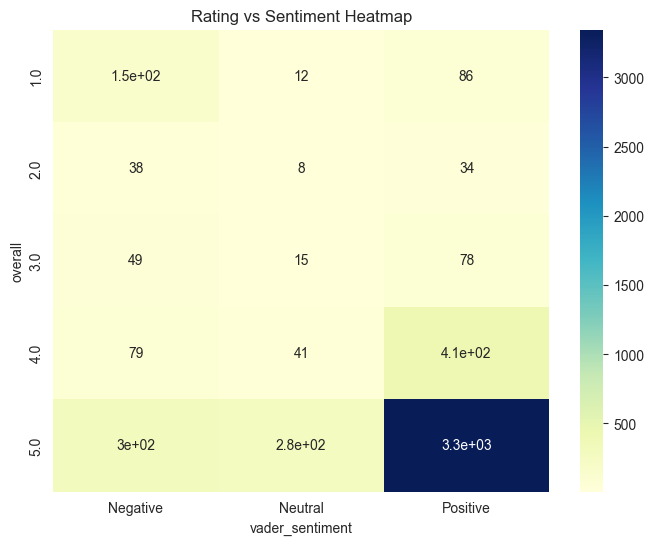

In [21]:
heat = pd.crosstab(
    df["overall"],
    df["vader_sentiment"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heat,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Rating vs Sentiment Heatmap")
plt.show()

### Insight

Higher ratings consistently align with stronger positive sentiment, validating the effectiveness of sentiment scoring methods.

## Subjectivity Analysis

Subjectivity measures whether a review expresses personal opinions or factual information.

- Subjectivity = 0 → Objective
- Subjectivity = 1 → Highly Opinionated

This analysis helps understand how customers express their experiences.

In [22]:
df["subjectivity"] = df["reviewText"].apply(
    lambda x: TextBlob(str(x)).sentiment.subjectivity
)

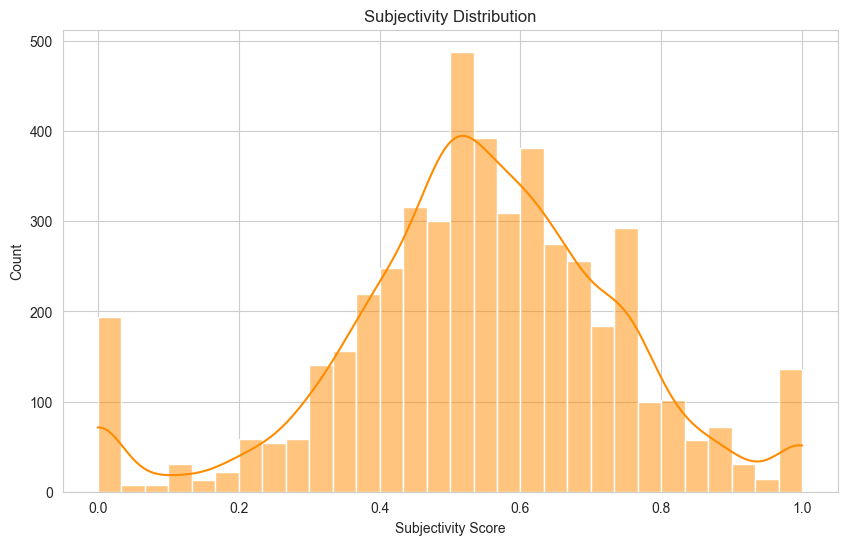

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["subjectivity"],
    bins=30,
    kde=True,
    color="darkorange"
)

plt.title("Subjectivity Distribution")
plt.xlabel("Subjectivity Score")

plt.show()

### Insight

Most reviews contain a moderate level of subjectivity, indicating that customers often combine factual descriptions with personal opinions.

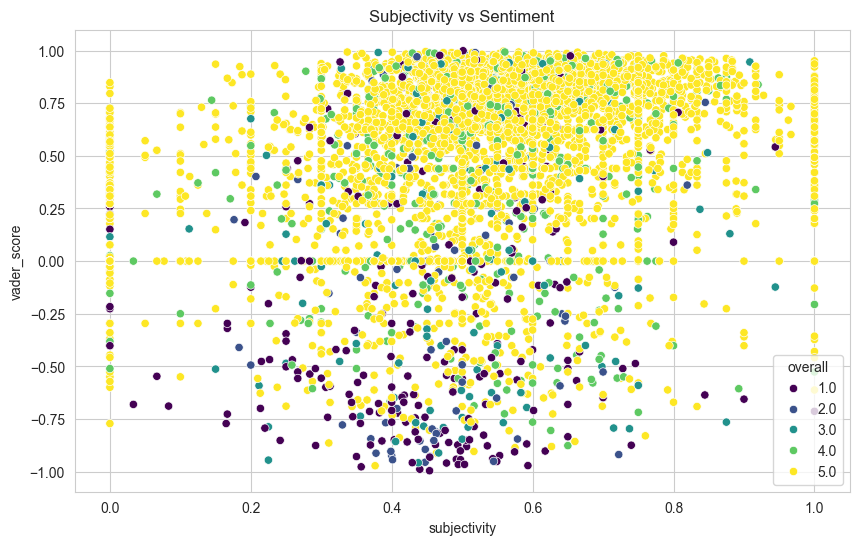

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="subjectivity",
    y="vader_score",
    hue="overall",
    palette="viridis",
    data=df
)

plt.title("Subjectivity vs Sentiment")

plt.show()

### Insight

Highly subjective reviews tend to show stronger emotions, resulting in more extreme sentiment scores.

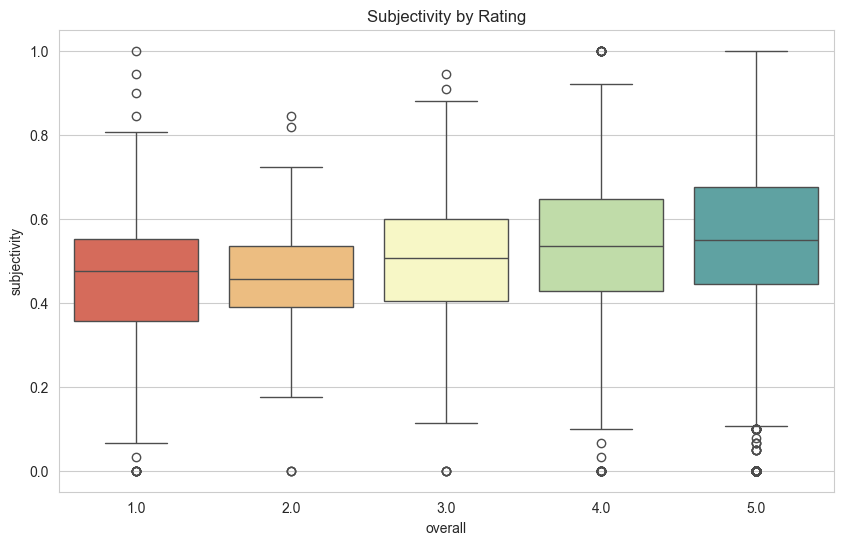

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="overall",
    y="subjectivity",
    data=df,
    palette="Spectral"
)

plt.title("Subjectivity by Rating")

plt.show()

## Word Cloud Analysis

Word clouds provide a visual representation of the most frequently occurring terms in customer reviews.

In [26]:
positive_reviews = " ".join(
    df[df["vader_sentiment"]=="Positive"]["reviewText"]
)

negative_reviews = " ".join(
    df[df["vader_sentiment"]=="Negative"]["reviewText"]
)

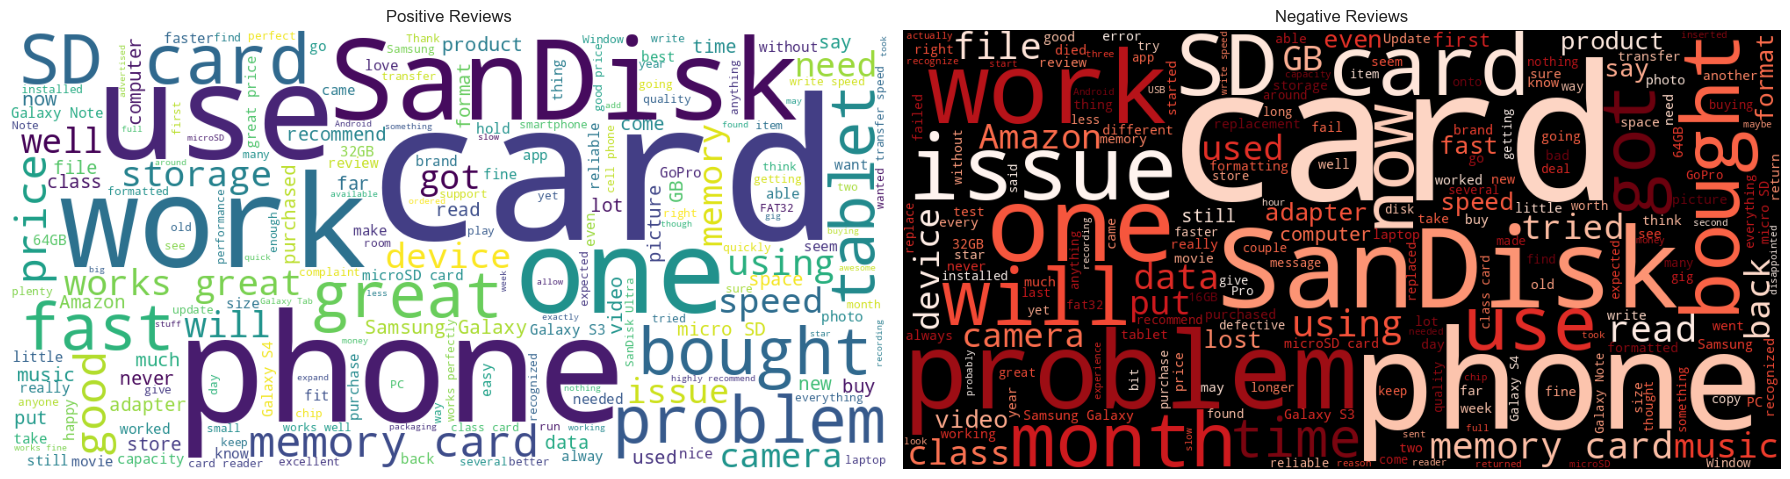

In [27]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18,7)
)

positive_wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate(positive_reviews)

negative_wc = WordCloud(
    width=1000,
    height=500,
    background_color="black",
    colormap="Reds"
).generate(negative_reviews)

axes[0].imshow(positive_wc)

axes[0].axis("off")

axes[0].set_title("Positive Reviews")

axes[1].imshow(negative_wc)

axes[1].axis("off")

axes[1].set_title("Negative Reviews")

plt.tight_layout()

plt.show()

### Insight

Positive reviews commonly contain appreciation-focused language, while negative reviews highlight complaints and product-related issues.

## Top Words Comparison

Identifying the most common words helps reveal recurring customer themes and concerns.

In [28]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]','',text)

    return text

In [29]:
positive_clean = clean_text(positive_reviews)

negative_clean = clean_text(negative_reviews)

In [30]:
positive_words = Counter(
    positive_clean.split()
).most_common(15)

negative_words = Counter(
    negative_clean.split()
).most_common(15)

In [31]:
pos_df = pd.DataFrame(
    positive_words,
    columns=["Word","Count"]
)

neg_df = pd.DataFrame(
    negative_words,
    columns=["Word","Count"]
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


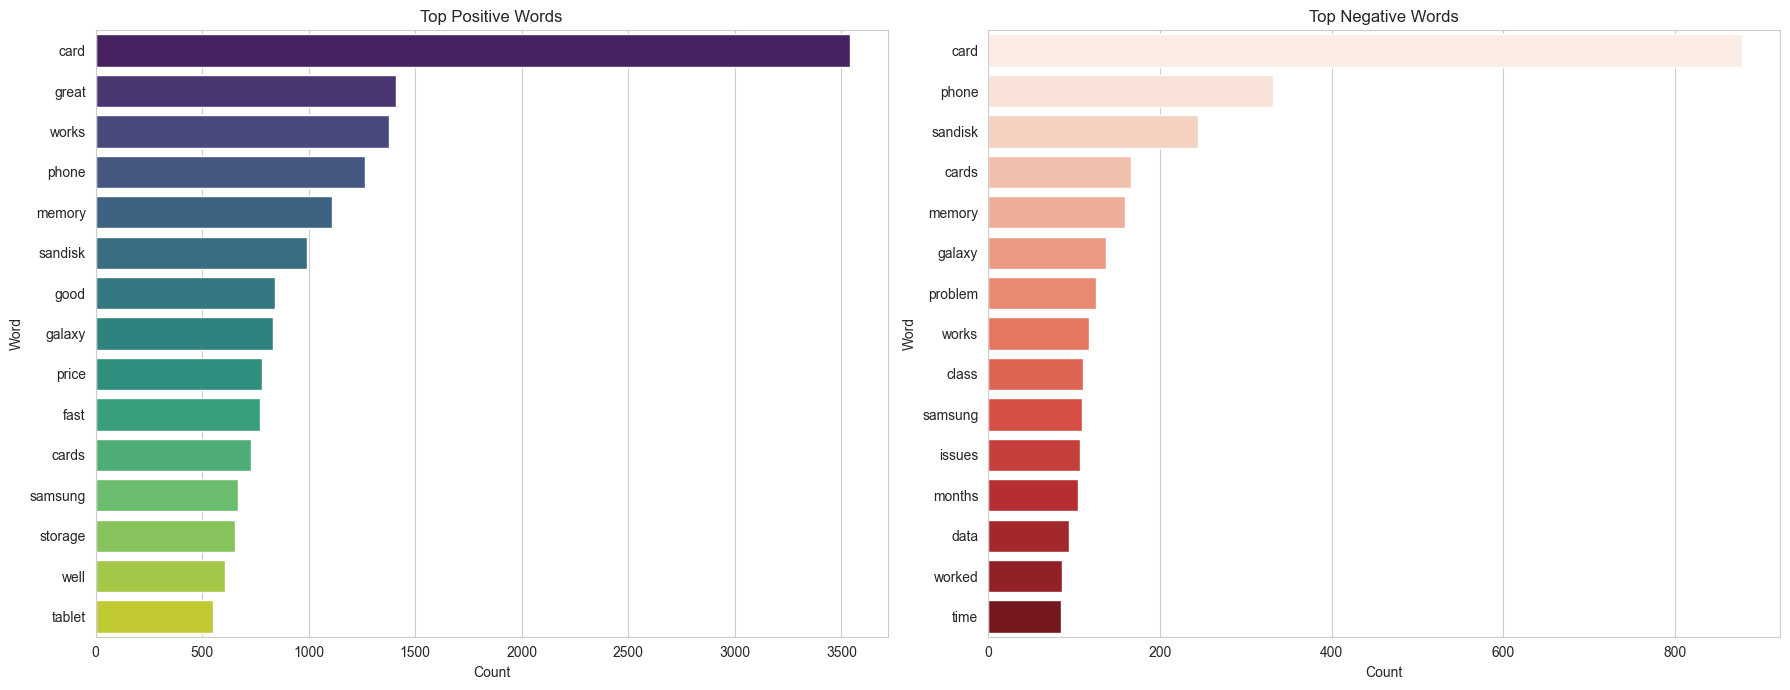

In [32]:
from nltk.corpus import stopwords
from collections import Counter
import nltk
import re

nltk.download('stopwords')

# Stopwords
stop_words = set(stopwords.words('english'))

# Custom words to remove
custom_words = {
    'amazon','product','item','buy','bought','purchase',
    'purchased','one','would','could','also','use',
    'used','using','get','got','like'
}

stop_words.update(custom_words)

# Clean text
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = [
        word for word in text.split()
        if word not in stop_words
        and len(word) > 2
    ]

    return words

# Positive words
positive_words = []

for review in df[df["vader_sentiment"]=="Positive"]["reviewText"]:
    positive_words.extend(clean_text(review))

# Negative words
negative_words = []

for review in df[df["vader_sentiment"]=="Negative"]["reviewText"]:
    negative_words.extend(clean_text(review))

# Top 15 words
pos_df = pd.DataFrame(
    Counter(positive_words).most_common(15),
    columns=["Word","Count"]
)

neg_df = pd.DataFrame(
    Counter(negative_words).most_common(15),
    columns=["Word","Count"]
)

# Plot
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18,7)
)

sns.barplot(
    data=pos_df,
    y="Word",
    x="Count",
    palette="viridis",
    ax=axes[0]
)

axes[0].set_title(
    "Top Positive Words"
)

sns.barplot(
    data=neg_df,
    y="Word",
    x="Count",
    palette="Reds",
    ax=axes[1]
)

axes[1].set_title(
    "Top Negative Words"
)

plt.tight_layout()
plt.show()

### Insight

Frequently used positive words reveal customer satisfaction drivers, while negative terms highlight recurring pain points.

## Review Length Analysis

Review length often reflects customer engagement and willingness to provide detailed feedback.

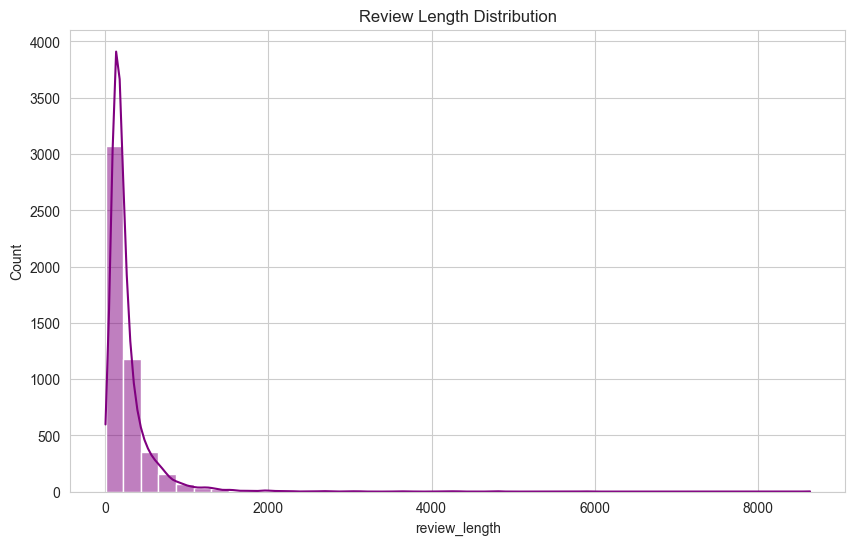

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["review_length"],
    bins=40,
    kde=True,
    color="purple"
)

plt.title("Review Length Distribution")

plt.show()

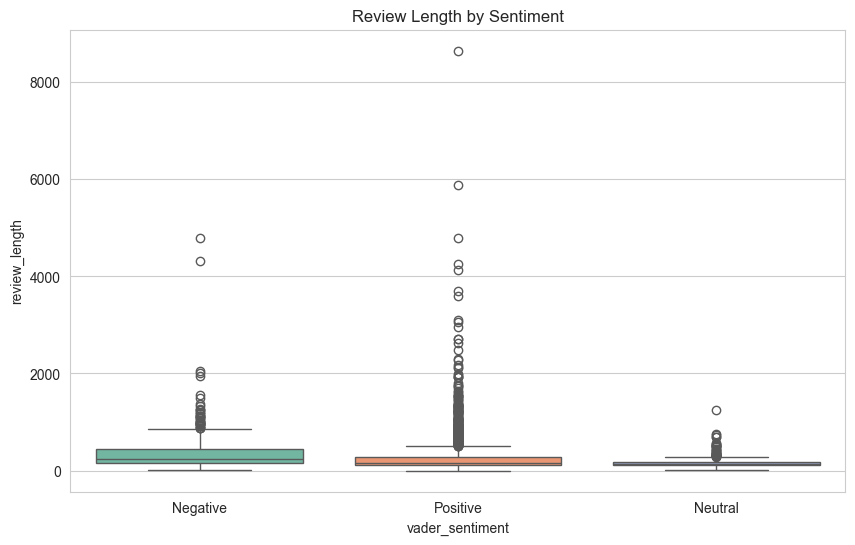

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="vader_sentiment",
    y="review_length",
    data=df,
    palette="Set2"
)

plt.title(
    "Review Length by Sentiment"
)

plt.show()

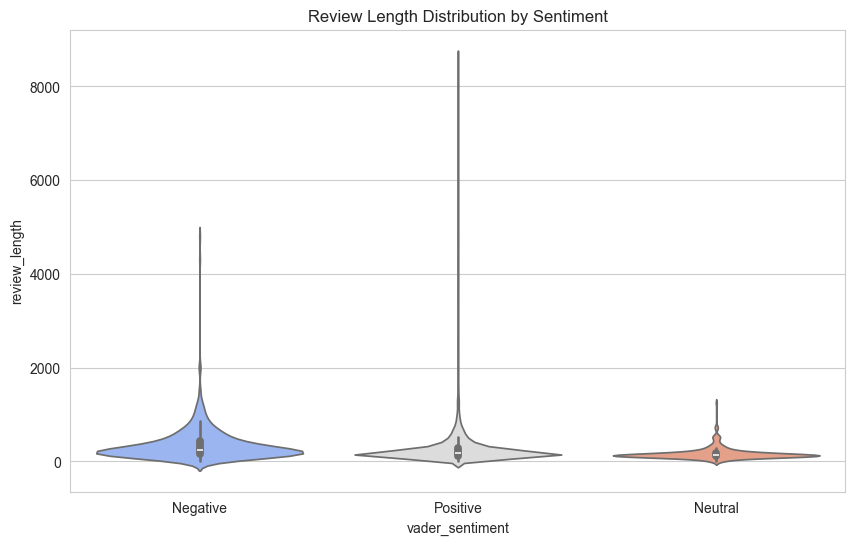

In [35]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x="vader_sentiment",
    y="review_length",
    data=df,
    palette="coolwarm"
)

plt.title(
    "Review Length Distribution by Sentiment"
)

plt.show()

### Insight

Negative reviews tend to be more detailed because customers often explain issues and dissatisfaction thoroughly.

## Helpfulness Analysis

Helpful votes indicate how useful customers found a review. This analysis helps identify characteristics of reviews that provide the most value to readers.

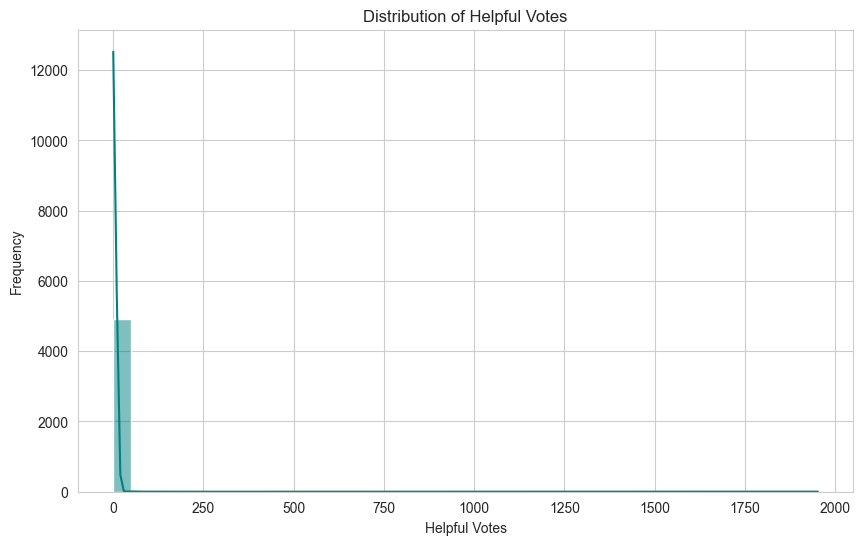

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["helpful_yes"],
    bins=40,
    kde=True,
    color="teal"
)

plt.title("Distribution of Helpful Votes")
plt.xlabel("Helpful Votes")
plt.ylabel("Frequency")

plt.show()

### Insight

Most reviews receive few helpful votes, while a small number of reviews attract significant community engagement.

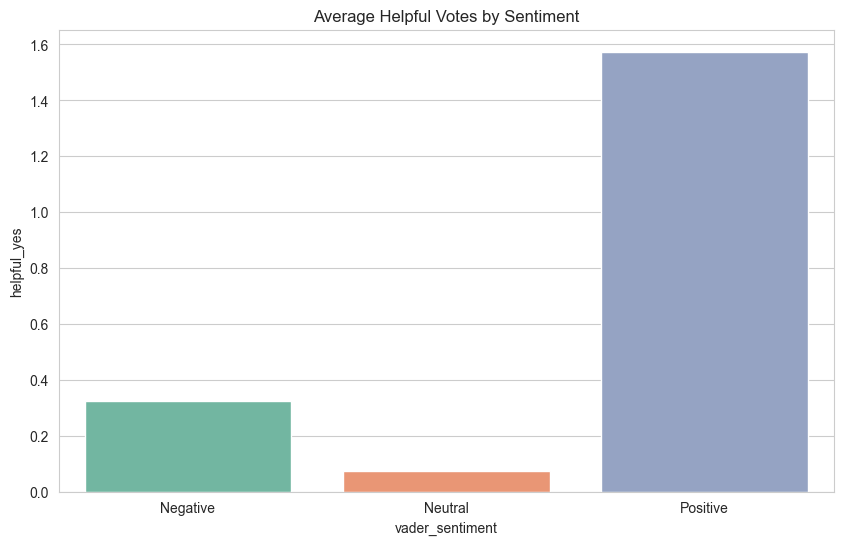

In [37]:
help_sent = (
    df.groupby("vader_sentiment")["helpful_yes"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=help_sent,
    x="vader_sentiment",
    y="helpful_yes",
    palette="Set2"
)

plt.title("Average Helpful Votes by Sentiment")

plt.show()

### Insight

Certain sentiment categories receive more helpful votes, suggesting that customers value detailed experiences regardless of whether they are positive or negative.

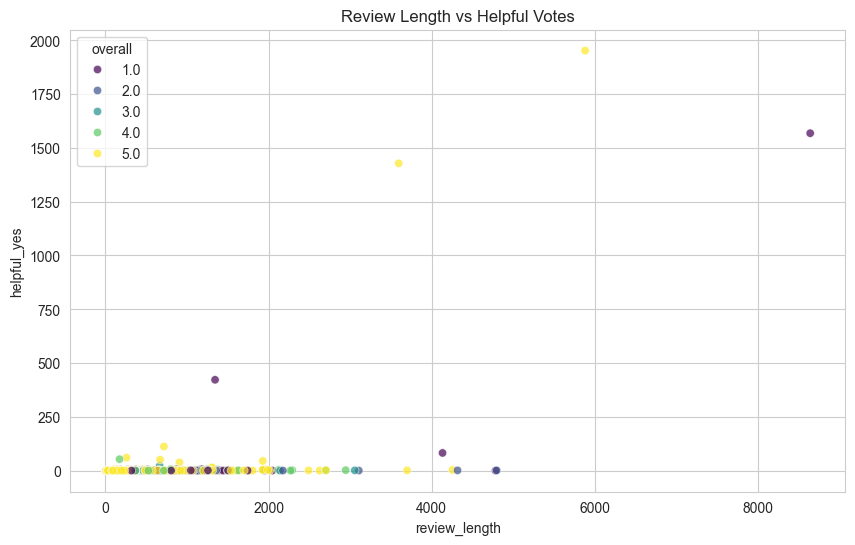

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="review_length",
    y="helpful_yes",
    hue="overall",
    palette="viridis",
    alpha=0.7
)

plt.title("Review Length vs Helpful Votes")

plt.show()

### Insight

Longer reviews generally receive more helpful votes because they provide richer information and detailed product experiences.

In [39]:
top_helpful = df.nlargest(
    10,
    "wilson_lower_bound"
)[["overall","helpful_yes","total_vote","wilson_lower_bound"]]

top_helpful

,overall,helpful_yes,total_vote,wilson_lower_bound
2031,5.0,1952,2020,0.957544
3449,5.0,1428,1505,0.936519
4212,1.0,1568,1694,0.912139
317,1.0,422,495,0.818577
4672,5.0,45,49,0.808109
1835,5.0,60,68,0.784651
3981,5.0,112,139,0.732136
3807,3.0,22,25,0.700442
4306,5.0,51,65,0.670334
4596,1.0,82,109,0.663595


### Insight

Wilson Lower Bound helps identify truly valuable reviews by balancing positive votes with review reliability.

## Review Trends Over Time

This section explores how review activity, ratings, and sentiment have changed over time.

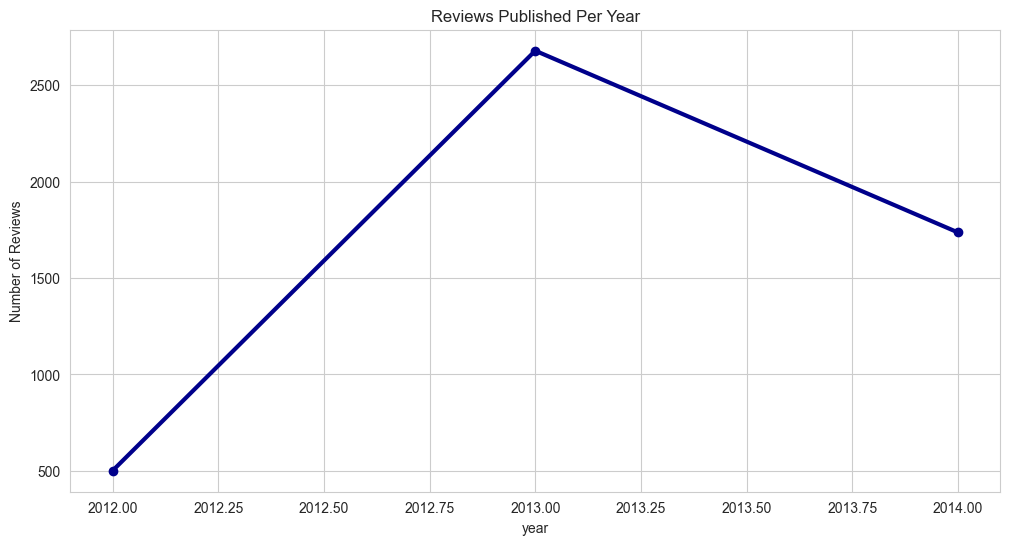

In [40]:
reviews_per_year = (
    df.groupby("year")
    .size()
)

plt.figure(figsize=(12,6))

reviews_per_year.plot(
    marker="o",
    linewidth=3,
    color="darkblue"
)

plt.title("Reviews Published Per Year")

plt.ylabel("Number of Reviews")

plt.show()

### Insight

Review volume trends reveal periods of increased customer engagement and product popularity.

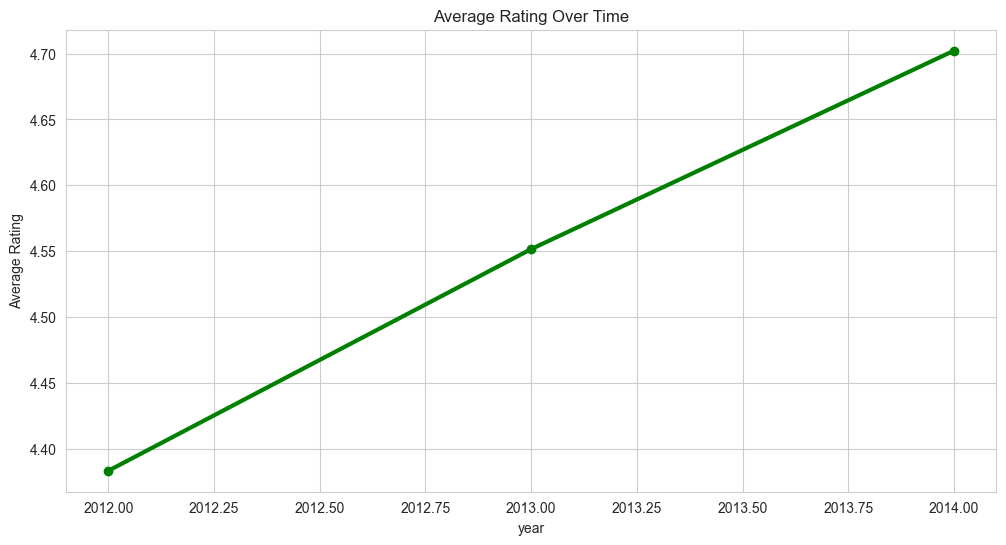

In [41]:
avg_rating_year = (
    df.groupby("year")["overall"]
    .mean()
)

plt.figure(figsize=(12,6))

avg_rating_year.plot(
    marker="o",
    linewidth=3,
    color="green"
)

plt.title("Average Rating Over Time")

plt.ylabel("Average Rating")

plt.show()

### Insight

Monitoring average ratings over time helps identify changes in customer satisfaction levels.

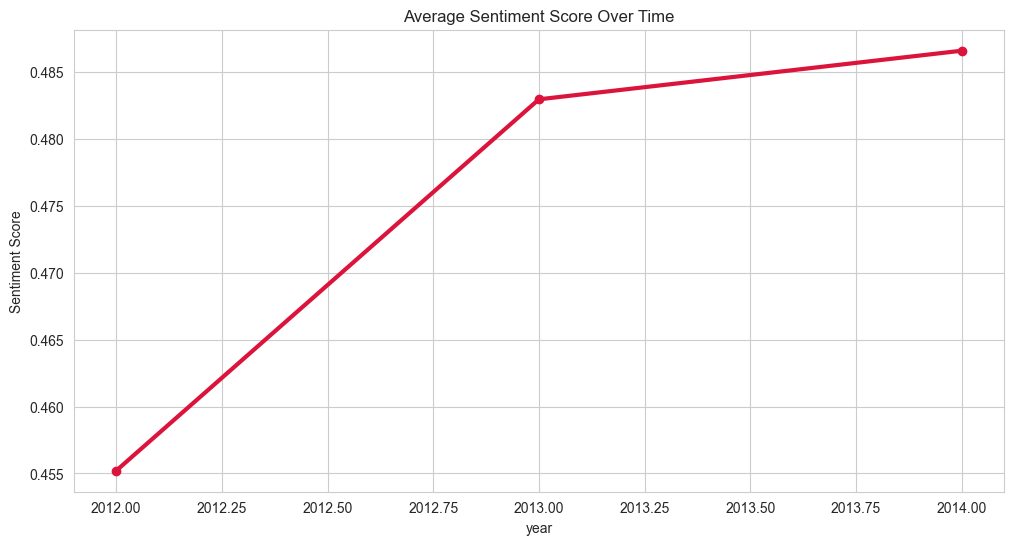

In [42]:
avg_sent_year = (
    df.groupby("year")["vader_score"]
    .mean()
)

plt.figure(figsize=(12,6))

avg_sent_year.plot(
    marker="o",
    linewidth=3,
    color="crimson"
)

plt.title("Average Sentiment Score Over Time")

plt.ylabel("Sentiment Score")

plt.show()

### Insight

Sentiment trends provide a deeper view of customer perception beyond simple star ratings.

## VADER vs TextBlob Agreement Analysis

Two sentiment models were applied to evaluate consistency and reliability of sentiment classification.

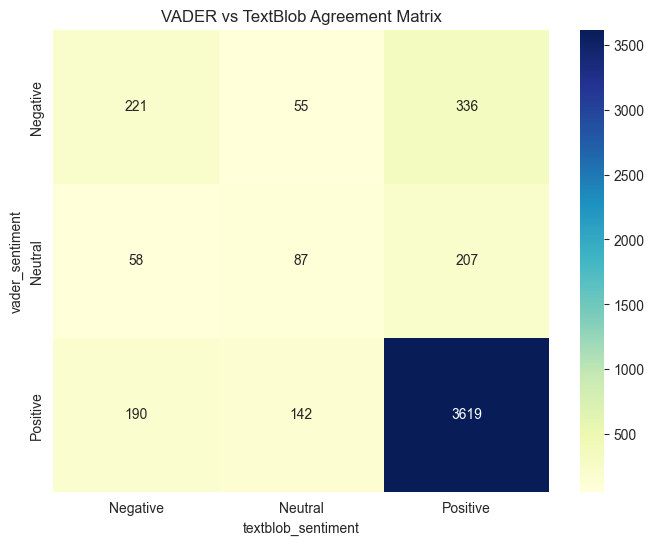

In [43]:
agreement = pd.crosstab(
    df["vader_sentiment"],
    df["textblob_sentiment"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    agreement,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("VADER vs TextBlob Agreement Matrix")

plt.show()

### Insight

The heatmap reveals where both models agree and where sentiment classifications differ.

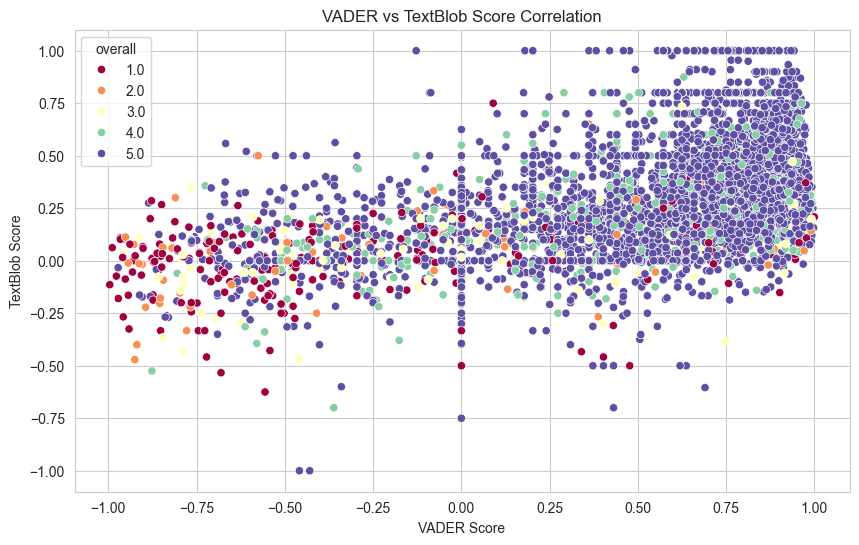

In [44]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["vader_score"],
    y=df["textblob_score"],
    hue=df["overall"],
    palette="Spectral"
)

plt.title("VADER vs TextBlob Score Correlation")

plt.xlabel("VADER Score")
plt.ylabel("TextBlob Score")

plt.show()

In [45]:
correlation = df["vader_score"].corr(
    df["textblob_score"]
)

print(
    f"Correlation Between Models: {correlation:.3f}"
)

Correlation Between Models: 0.494


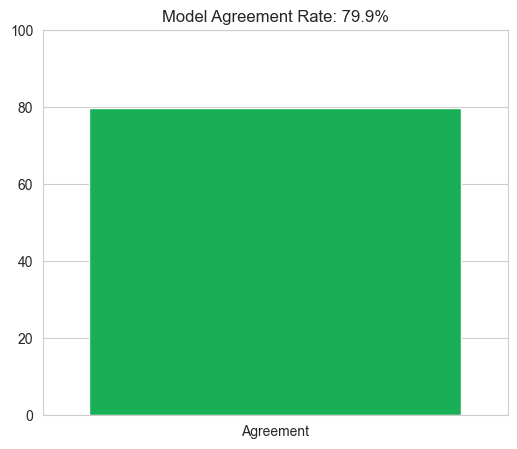

In [46]:
agreement_rate = (
    (
        df["vader_sentiment"]
        ==
        df["textblob_sentiment"]
    ).mean()
) * 100

plt.figure(figsize=(6,5))

sns.barplot(
    x=["Agreement"],
    y=[agreement_rate],
    palette=["#00C853"]
)

plt.ylim(0,100)

plt.title(
    f"Model Agreement Rate: {agreement_rate:.1f}%"
)

plt.show()

### Insight

A high agreement percentage indicates consistency between sentiment analysis approaches and strengthens confidence in the results.

## Executive Dashboard

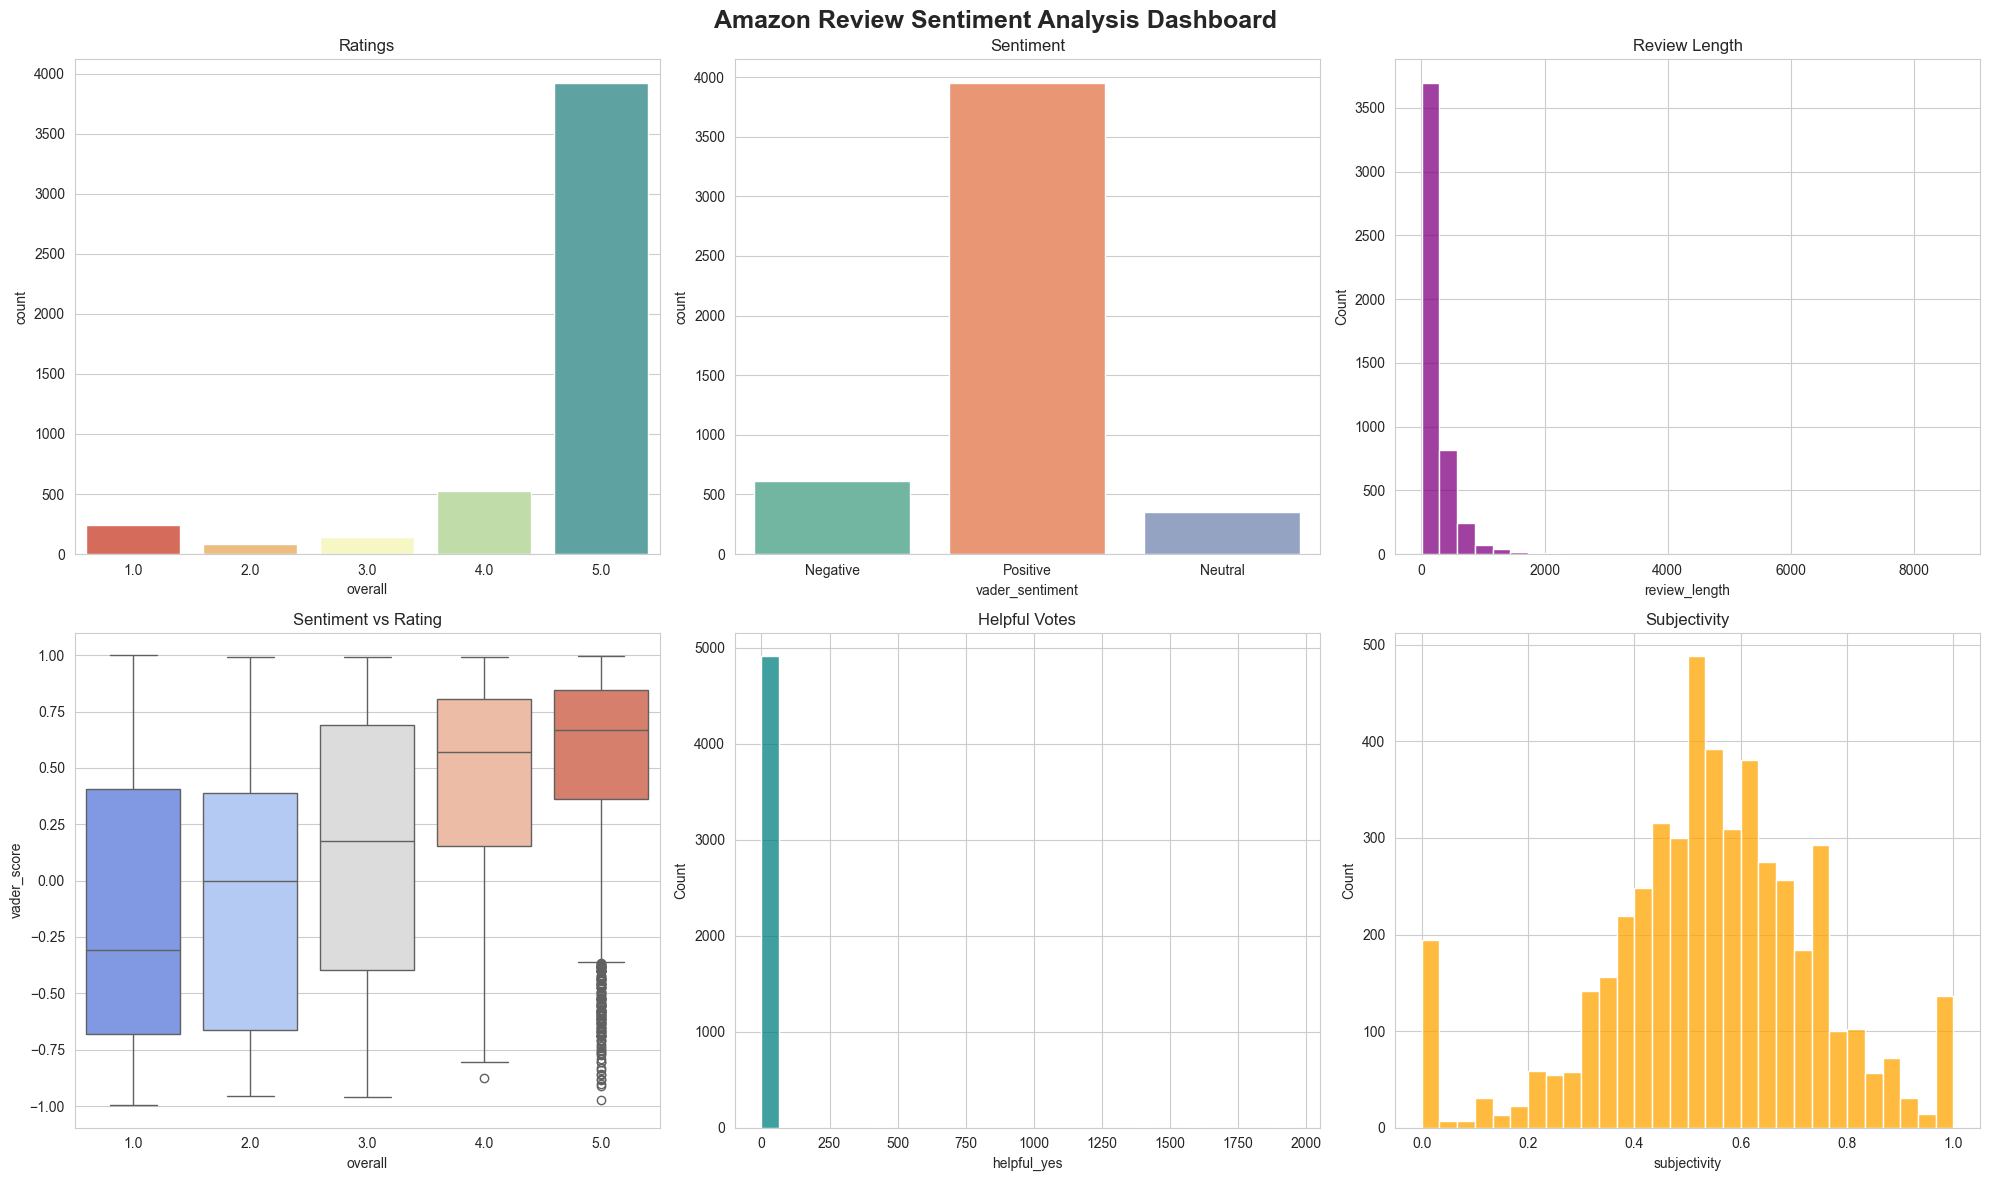

In [47]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(20,12)
)

# Rating Distribution
sns.countplot(
    x="overall",
    data=df,
    palette="Spectral",
    ax=axes[0,0]
)
axes[0,0].set_title("Ratings")

# Sentiment Distribution
sns.countplot(
    x="vader_sentiment",
    data=df,
    palette="Set2",
    ax=axes[0,1]
)
axes[0,1].set_title("Sentiment")

# Review Length
sns.histplot(
    df["review_length"],
    bins=30,
    color="purple",
    ax=axes[0,2]
)
axes[0,2].set_title("Review Length")

# Sentiment by Rating
sns.boxplot(
    x="overall",
    y="vader_score",
    data=df,
    palette="coolwarm",
    ax=axes[1,0]
)
axes[1,0].set_title("Sentiment vs Rating")

# Helpful Votes
sns.histplot(
    df["helpful_yes"],
    bins=30,
    color="teal",
    ax=axes[1,1]
)
axes[1,1].set_title("Helpful Votes")

# Subjectivity
sns.histplot(
    df["subjectivity"],
    bins=30,
    color="orange",
    ax=axes[1,2]
)
axes[1,2].set_title("Subjectivity")

plt.suptitle(
    "Amazon Review Sentiment Analysis Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

##  Final Summary

## Key Findings

| Finding | Business Impact |
|----------|----------|
| Positive reviews dominate the dataset | Indicates strong customer satisfaction |
| Higher ratings align closely with positive sentiment | Validates sentiment classification results |
| Negative reviews are generally longer | Customers provide detailed explanations when dissatisfied |
| Helpful reviews tend to be more detailed | Rich content improves review usefulness |
| VADER and TextBlob show strong agreement | Sentiment findings are reliable |
| Subjective reviews often contain stronger emotions | Customer opinions drive sentiment intensity |
| Review trends remain largely positive over time | Product perception remains favorable |

## Conclusion

This analysis demonstrates how Natural Language Processing (NLP) and sentiment analysis can transform unstructured customer reviews into actionable business insights. By combining VADER, TextBlob, visualization, and review quality metrics, organizations can better understand customer opinions, improve products, and enhance customer experience.